### Installing Core Dependencies for LangGraph & OpenAI Agents

In [12]:
!pip install --quiet langchain-openai langgraph python-dotenv pydantic

### Setting Up OpenAI API Key Using Environment Variables

In [13]:
import os

# Replace "YOUR_OPENAI_API_KEY" with your actual key, or set it via Colab Secrets.
os.environ["OPENAI_API_KEY"] = ""


### Importing Core Libraries for LangGraph Agent Development

In [14]:
from typing import List, Optional, Literal, Annotated
from typing_extensions import TypedDict
from pydantic import BaseModel, Field, validator
from dotenv import load_dotenv

from langchain_core.messages import HumanMessage
from langchain_openai import ChatOpenAI

from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode
from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.checkpoint.memory import MemorySaver


### Defining Pydantic Models : Structured Data Models for Resume and Job Parsing Using Pydantic

In [15]:
# Defining the Work Experience Schema
class WorkExperience(BaseModel):
    job_title: str = Field(description="Job title or position.")
    company: str = Field(description="The company name.")
    experience: int = Field(description="Years of experience in the job.")
    responsibilities: List[str] = Field(description="List of responsibilities in the job.")

# Defining the Education Schema
class Education(BaseModel):
    degree: str = Field(description="Degree obtained.")
    school: str = Field(description="The university name.")
    major: str = Field(description="Major subject.")
    year: Optional[int] = Field(description="Year of graduation.")

    @validator('year', pre=True, always=True)
    def set_year(cls, v):
        return v if v is not None else 0

# Creating a Structured Resume Model
class Resume(BaseModel):
    """Structured resume data."""
    name: str = Field(description="Name of the person")
    professional_summary: str = Field(description="Professional summary of the person.")
    work_experience: List[WorkExperience] = Field(description="List of work experiences held by the person.")
    education: List[Education] = Field(description="List of educational qualifications of the person.")
    skills: List[str] = Field(description="List of skills relevant to the jobs.")

    # Generating Sample Resume Data for Testing
    @classmethod
    def mock(cls):
        return cls(
            name='Jeff',
            professional_summary=(
                'Innovative software engineer with 8+ years of experience in the tech industry. '
                'Senior Developer at Company X, Freelance Software Architect, and Junior Developer at Company Y. '
                'Proficient in developing scalable applications, optimizing system performance, and leading cross-functional teams. '
                'Fluent in English and Spanish.'
            ),
            work_experience=[
                WorkExperience(
                    job_title='Senior Developer',
                    company='Company X',
                    experience=5,
                    responsibilities=[
                        'Led the development of scalable web applications',
                        'Optimized system performance and reduced server costs',
                        'Mentored junior developers and conducted code reviews',
                        'Collaborated with product managers to define project requirements',
                        'Implemented CI/CD pipelines to streamline deployments',
                        'Developed RESTful APIs for mobile and web applications',
                        'Ensured application security and compliance with industry standards'
                    ]
                ),
                WorkExperience(
                    job_title='Freelance Software Architect',
                    company='Independent Consultant',
                    experience=2,
                    responsibilities=[
                        'Designed software architecture for various clients',
                        'Provided technical consultancy and project management',
                        'Developed custom software solutions to meet client needs',
                        'Conducted system analysis and performance tuning',
                        'Integrated third-party services and APIs',
                        'Created technical documentation and user manuals'
                    ]
                ),
                WorkExperience(
                    job_title='Junior Developer',
                    company='Company Y',
                    experience=1,
                    responsibilities=[
                        'Assisted in the development of web applications',
                        'Performed bug fixes and code maintenance',
                        'Collaborated with senior developers on project tasks',
                        'Participated in daily stand-ups and sprint planning',
                        'Wrote unit tests to ensure code quality',
                        'Contributed to open-source projects'
                    ]
                )
            ],
            education=[
                Education(
                    degree='BS Computer Science',
                    school='X University',
                    major='Computer Science',
                    year=1999
                )
            ],
            skills=[
                'Software Architecture',
                'System Optimization',
                'Team Mentorship',
                'Project Management',
                'API Development',
                'Continuous Integration/Continuous Deployment',
                'Bilingual'
            ]
        )

# Defining the Job Posting Schema
class Job(BaseModel):
    title: str = Field(description="Job title or position.")
    company: str = Field(description="The company name.")
    location: Optional[str] = Field(description="Location of the job.")
    salary: Optional[str] = Field(description="Salary range for the job.")
    description: str = Field(description="Detailed job description.")
    responsibilities: List[str] = Field(description="List of job responsibilities.")
    benefits: Optional[List[str]] = Field(description="List of job benefits.")
    employment_type: Optional[str] = Field(description="Type of employment (e.g., full-time, part-time).")
    posted_date: Optional[str] = Field(description="Date when the job was posted.")

    # Generating Sample Job Posting Data
    @classmethod
    def mock(cls):
        return cls(
            title='Software Engineer',
            company='Tech Corp',
            location='San Francisco, CA',
            salary='$100,000 - $120,000',
            description='We are looking for a skilled Software Engineer to join our team.',
            responsibilities=[
                "Develop and maintain web applications",
                "Collaborate with cross-functional teams",
                "Write clean, scalable, and efficient code",
                "Participate in code reviews",
                "Troubleshoot and debug applications"
            ],
            benefits=[
                "Health insurance",
                "401(k) matching",
                "Paid time off",
                "Flexible working hours"
            ],
            employment_type='Full-time',
            posted_date='2024-10-01'
        )


/tmp/ipykernel_681/1805201273.py:15: PydanticDeprecatedSince20: Pydantic V1 style `@validator` validators are deprecated. You should migrate to Pydantic V2 style `@field_validator` validators, see the migration guide for more details. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.13/migration/
  @validator('year', pre=True, always=True)


### Tool Definitions: Creating Agent Tools for Accessing Resume and Job Data

In [16]:
# Creating a Job Data Retrieval Function
def process_job() -> Job:
    """Return a mock Job object (in production, fetch from DB or API)."""
    return Job.mock()

# Creating a Resume Data Retrieval Function
def process_resume() -> Resume:
    """Return a mock Resume object (in production, fetch from DB or API)."""
    return Resume.mock()

# Building a Job Information Retrieval Tool
@tool
def get_job(field: Optional[Literal[
    'title', 'company', 'location', 'salary', 'description',
    'responsibilities', 'benefits', 'employment_type', 'posted_date'
]] = None) -> str:
    """
    Get job data.
    If `field` is provided, return that attribute; else return full dict.
    """
    job = process_job()
    if field:
        return getattr(job, field)
    return job.model_dump()

# Building a Resume Information Retrieval Tool
@tool
def get_resume(field: Optional[Literal[
    'name', 'professional_summary', 'work_experience', 'education', 'skills'
]] = None) -> str:
    """
    Get resume data.
    If `field` is provided, return that attribute; else return full dict.
    """
    resume = process_resume()
    if field:
        return getattr(resume, field)
    return resume.model_dump()


### Build the LangGraph Agent - Creating a Tool-Augmented Resume Expert Agent

In [17]:
# Initializing the GPT-4o Language Model with Tool Binding
llm = ChatOpenAI(
    model_name="gpt-4o",
    api_key=os.getenv("OPENAI_API_KEY")
).bind_tools([get_job, get_resume])

# Defining the Expert Agent Node in LangGraph
def expert(state: MessagesState):
    """
    The 'expert' node:
    - Prepend a system prompt
    - Forward user messages (and any prior conversation) into the LLM.
    """
    system_message = """
You are a resume expert. You are tasked with improving the user's resume based on a job description.
You can access both the resume and the job data using the provided tools: get_resume and get_job.

IMPORTANT:
- You must NEVER invent skills, experiences, or education that the user does not already have.
- If asked for any detail not in the resume, either fetch via tool or state that the information is unavailable.
"""
    # Retrieving Conversation History from State
    messages = state["messages"]

    # Invoke the LLM with the system prompt plus the conversation history
    response = llm.invoke([system_message] + messages)

    # Returning the Agent Response to LangGraph
    return {"messages": [response]}


### Building and Compiling a Tool-Calling LangGraph Agent

In [18]:
# Creating a Tool Execution Node
tool_node = ToolNode([get_job, get_resume])

# Initializing the LangGraph Workflow
graph = StateGraph(MessagesState)

# Adding the Expert Agent Node
graph.add_node("expert", expert)

# Adding the Tool Execution Node
graph.add_node("tools", tool_node)

# Defining the Workflow Entry Point - Edge from START to expert
graph.add_edge(START, "expert")

# Implementing Conditional Routing Logic - If the LLM’s response contains a tool call, route to the tools node; else end.
def should_continue(state: MessagesState) -> Literal["tools", END]:
    # Checking Whether the Agent Requested a Tool and retrieve the latest assistant message
    last_msg = state["messages"][-1]
    if last_msg.tool_calls:
        return "tools"
    # Ending the Workflow When No Tool Is Needed
    return END

# Adding Dynamic Workflow Routing
graph.add_conditional_edges("expert", should_continue)

# Creating the Tool-to-Agent Feedback Loop
graph.add_edge("tools", "expert")

# MemorySaver for conversation history
checkpointer = MemorySaver()

# Compile the graph into a runnable app
app = graph.compile(checkpointer=checkpointer)

### Visualizing the LangGraph Workflow Structure

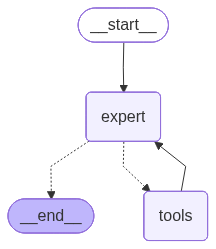

In [19]:
from IPython.display import Image, display
display(Image(app.get_graph(xray=True).draw_mermaid_png()))

### Creating a Sample User Query for Resume Optimization

In [20]:
example_query = "Please review my resume and suggest optimizations so that it matches the Software Engineer position requirements at Tech Corp."


### Invoking the LangGraph Agent with a User Query

In [21]:
# Invoke the agent once (no prior history besides this prompt).
result = app.invoke(
    {"messages": [HumanMessage(content=example_query)]},
    config={"configurable": {"thread_id": 1}}
)

### Displaying the Agent's Final Response

In [22]:
print("Agent Response:\n")
print(result["messages"][-1].content)

Agent Response:

Based on the job description for the Software Engineer position at Tech Corp and your current resume, here are several recommendations to optimize your resume and align it more closely with the job requirements:

### Professional Summary
- **Adjustment**: Your summary is strong and mentions key skills that align well with the job description. Consider emphasizing specifically "web applications" development and "code efficiency" as these directly match the job requirements.
- **Suggestion**: Tailor it by adding direct mention of "collaborating with cross-functional teams" and "debugging applications."

### Work Experience
- **Senior Developer at Company X**:
  - **Additions**: Highlight specific achievements in leading cross-functional teams to align with Tech Corp’s desire for collaboration.
  - **Current Mention**: You already have responsibilities that match closely with those needed by Tech Corp, such as developing scalable web applications and conducting code revie